In [24]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.preprocessing import StandardScaler

### 1. EDA

In [3]:
### load the dataset
df=pd.read_csv('wine.csv')

In [4]:
### Size of data
df.shape

(178, 14)

In [5]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
### First five rows of data
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
### Statistical Summary
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
### Check Duplicates
df.duplicated().sum()

np.int64(0)

    No Duplicates

In [9]:
### Check Missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

    No Missing values

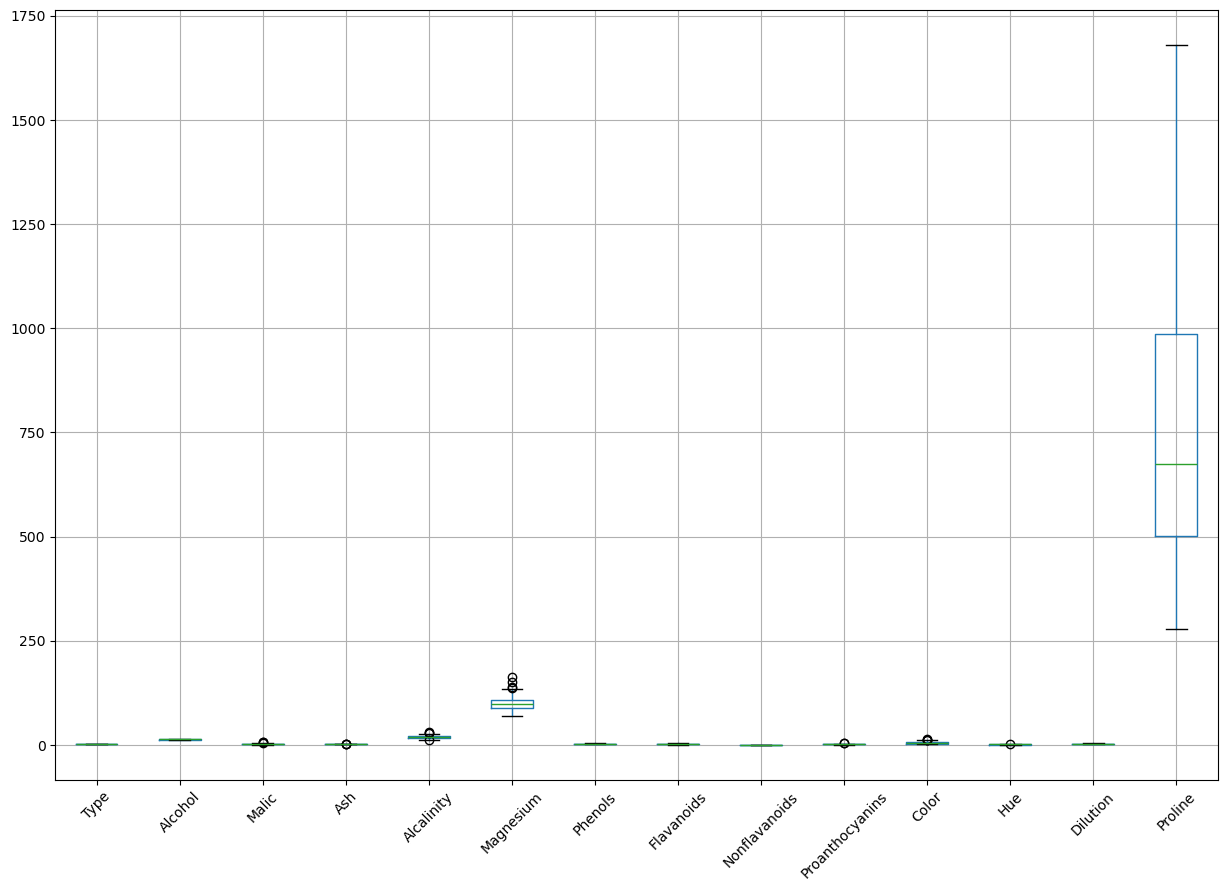

In [10]:
### Check Outliers
plt.figure(figsize=(15,10))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [11]:
### Outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

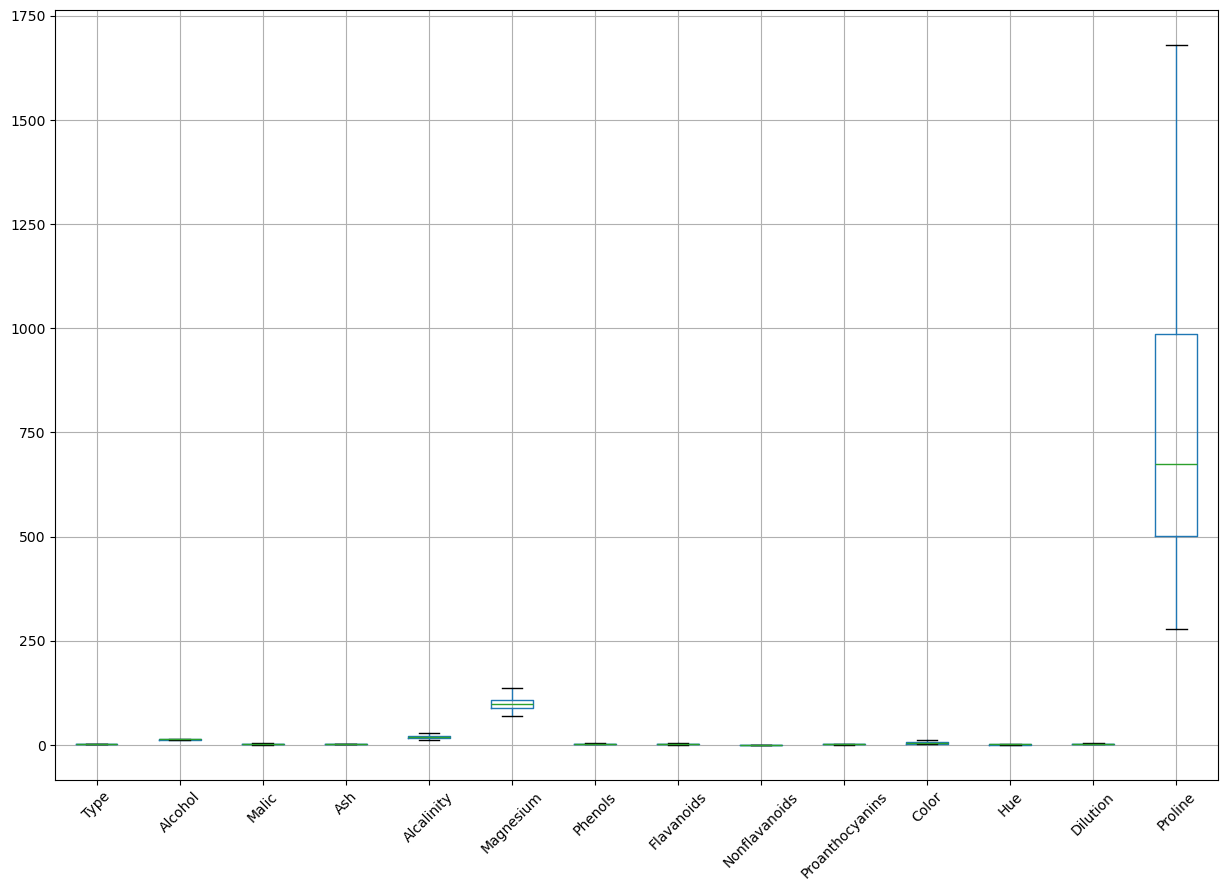

In [12]:
### After Capping
### Check Outliers
plt.figure(figsize=(15,10))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

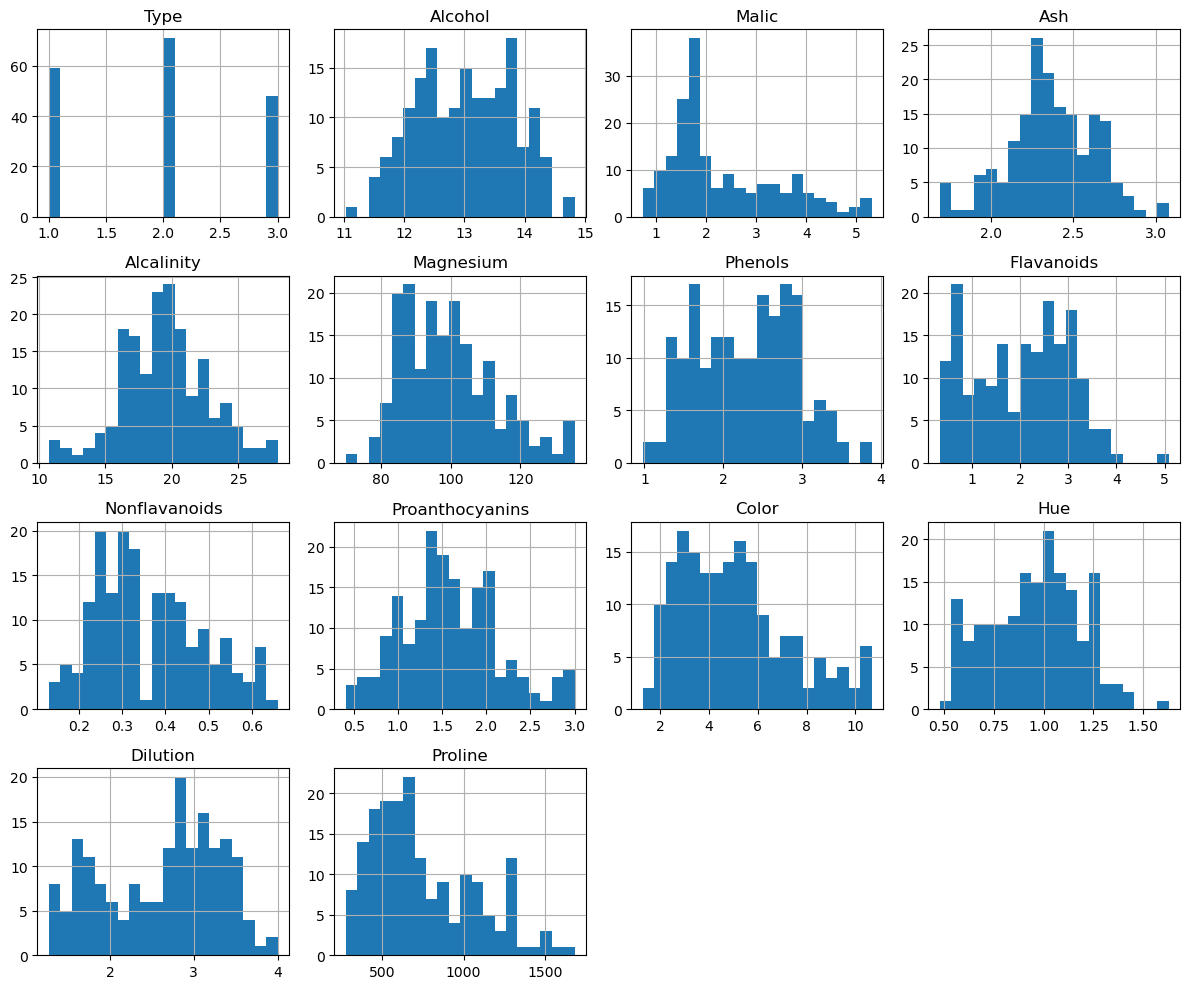

In [13]:
### Histogram
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

* Most features show a continuous distribution with values spread across different ranges.
* Alcohol, Magnesium, Phenols, and Proline have a wide range of values.
* Malic, Flavanoids, and Color show slightly skewed distributions.
* The Type column has three classes, indicating the dataset contains three wine categories.
* Overall, the features have different distributions, which makes standardization necessary before applying PCA.

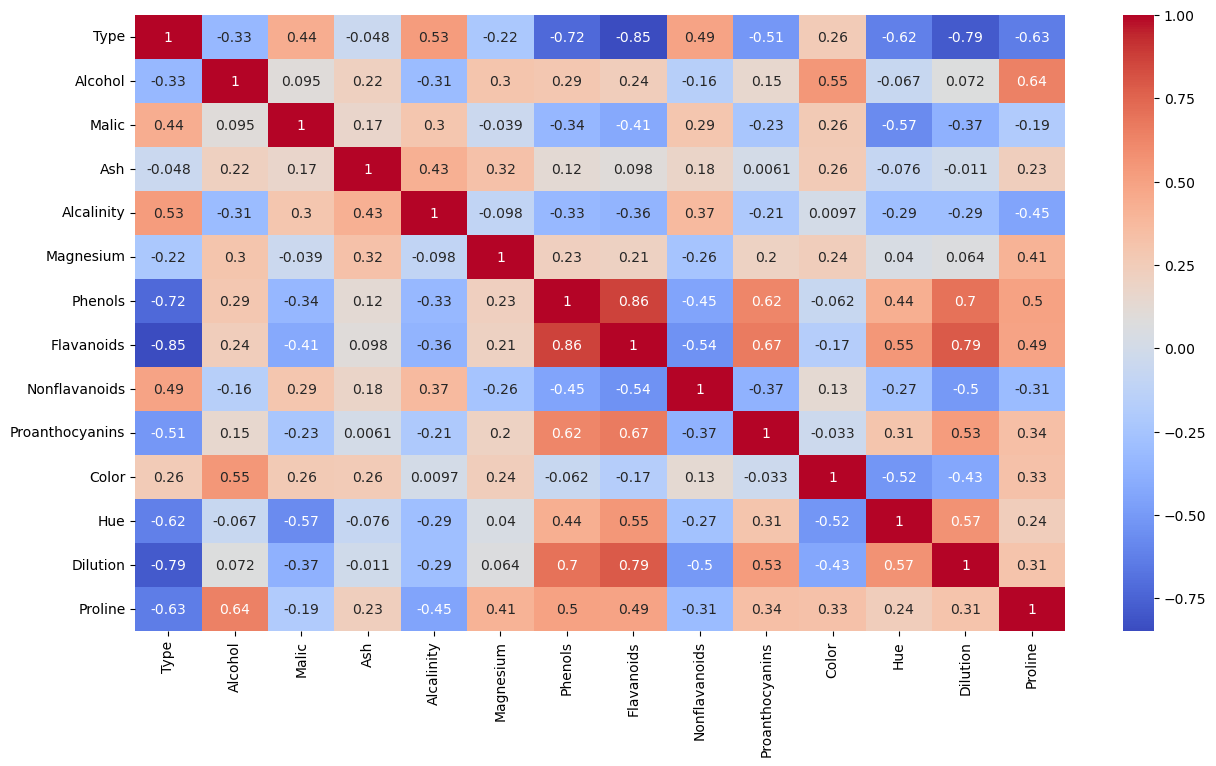

In [14]:
### Correlation heatmap
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

* The heatmap shows the relationship between all features.
* Phenols and Flavanoids have the highest positive correlation (0.86).
* Flavanoids and Dilution (0.79) and Phenols and Dilution (0.70) are also strongly correlated.
* Type has a strong negative correlation with Flavanoids (-0.85) and Dilution (-0.79).
* Most other features have weak to moderate correlations.
* The presence of highly correlated features makes the dataset suitable for PCA.

### 2. Dimensionality Reduction with PCA

In [15]:
### Seperate the target and features
target=df[['Type']]
features=df.drop(columns=['Type'])

In [16]:
### Standardization
std_sc = StandardScaler()
features_scaled = std_sc.fit_transform(features)

In [17]:
### PCA Implementation
pca = PCA()
pca_data = pca.fit_transform(features_scaled)

In [18]:
### Explained variance of each principal component
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.36475803 0.19609775 0.10911182 0.07062378 0.06296983 0.04815067
 0.04031504 0.02744533 0.02232516 0.01931106 0.01755433 0.01326634
 0.00807088]


* PC1 explains 36.48% of the total variance.
* PC2 explains 19.61% of the variance.
* PC3 explains 10.91% of the variance.
* The explained variance decreases with each additional principal component.
* The first few principal components capture most of the information in the dataset.

In [19]:
### Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.36475803 0.56085577 0.66996759 0.74059137 0.8035612  0.85171187
 0.89202691 0.91947224 0.9417974  0.96110846 0.97866279 0.99192912
 1.        ]


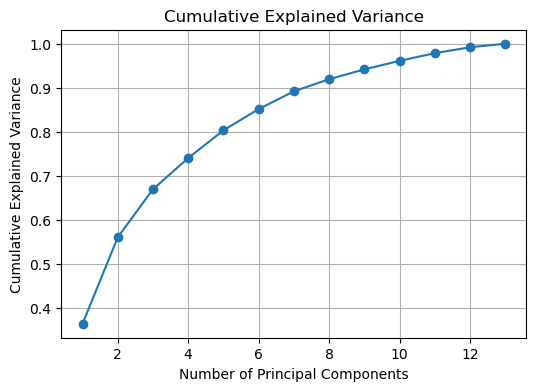

In [20]:
### Plot cumulative explained variance
plt.figure(figsize=(6,4))

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid()
plt.show()

* The cumulative explained variance increases as more principal components are added.
* The first 8 principal components explain about 92% of the total variance.
* Around 10 principal components explain about 96% of the variance.
* Nearly 100% of the variance is captured by all 13 principal components.
* Based on the graph, 10 principal components are sufficient to retain most of the information while reducing the dataset size.

In [21]:
# Apply PCA with 10 principal components
pca = PCA(n_components=10)

pca_data = pca.fit_transform(features_scaled)

print(pca_data.shape)

(178, 10)


In [22]:
# Convert PCA-transformed data into a DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=[f'PC{i+1}' for i in range(10)]
)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566


* The original features have been transformed into 10 principal components (PC1–PC10).
* Each principal component is a combination of the original features.
* The transformed dataset has 10 features instead of 13, while preserving about 96% of the original information.
* This reduced dataset can now be used for K-Means clustering and further analysis.

### 3. Clustering with Original Data

In [25]:
from sklearn.cluster import KMeans

In [26]:
# Apply K-Means clustering to the original data
kmeans = KMeans(n_clusters=3, random_state=50)

original_clusters = kmeans.fit_predict(features_scaled)

print(original_clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


C:\Users\rskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
# Add cluster labels to the dataset
df['Cluster'] = original_clusters

df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Cluster
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


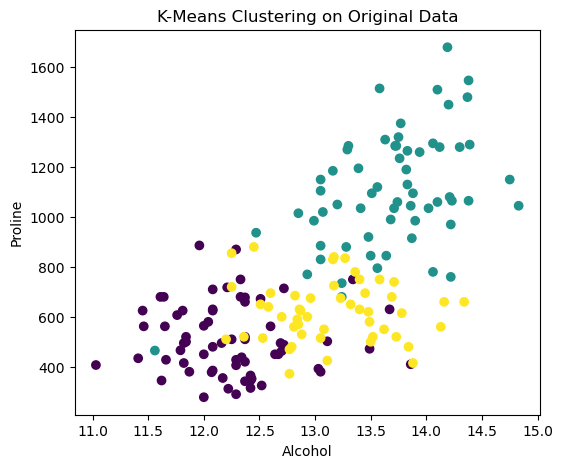

In [28]:
plt.figure(figsize=(6,5))

plt.scatter(df['Alcohol'],
            df['Proline'],
            c=original_clusters,
            cmap='viridis')

plt.xlabel("Alcohol")
plt.ylabel("Proline")
plt.title("K-Means Clustering on Original Data")

plt.show()

In [31]:
silhouette = silhouette_score(features_scaled, original_clusters)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.2852866569627524


* The Silhouette Score is 0.2853.
* This indicates that the clusters are reasonably separated, but there is some overlap between them.
* A higher silhouette score indicates better-defined clusters.
* Overall, the clustering performance is moderate.

### 4. Clustering with PCA Data

In [36]:
# Apply K-Means clustering on PCA-transformed data
kmeans_pca = KMeans(n_clusters=3, random_state=50)

pca_clusters = kmeans_pca.fit_predict(pca_data)

print(pca_clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


C:\Users\rskar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [37]:
# Add PCA cluster labels
pca_df['Cluster'] = pca_clusters

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Cluster
0,3.358147,1.520222,-0.126375,-0.224356,0.710891,0.176645,0.701154,0.019187,-0.689257,-1.031209,1
1,2.229215,-0.333261,-2.042838,-0.365783,-0.107448,0.984902,0.048001,0.991649,0.379664,-0.208787,1
2,2.540057,1.036953,1.018845,0.766907,-0.363113,-0.537666,0.412691,-0.464401,1.164755,-0.136538,1
3,3.781124,2.782566,-0.149224,0.593304,-0.273054,-0.132210,-0.394978,0.694895,-0.001904,-0.241293,1
4,1.016872,0.955225,2.113169,-0.431732,0.357108,0.386733,0.487160,0.377559,-0.283486,0.036566,1


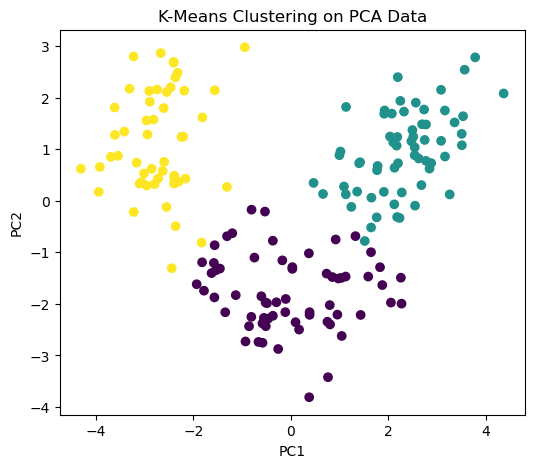

In [38]:
# Visualize clusters using the first two principal components
plt.figure(figsize=(6,5))

plt.scatter(pca_df['PC1'],
            pca_df['PC2'],
            c=pca_clusters,
            cmap='viridis')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering on PCA Data")

plt.show()

* The PCA-transformed data is grouped into three distinct clusters.
* The clusters are more clearly separated than in the original data.
* There is less overlap between the clusters, making them easier to distinguish.
* PC1 and PC2 effectively capture the important information for clustering.
* Overall, PCA improves the visualization and makes the cluster structure clearer.

In [40]:
silhouette = silhouette_score(pca_data, pca_clusters)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.29924068448082314


* The Silhouette Score is 0.2992.
* This score is slightly higher than the score for the original data (0.2853).
* A higher silhouette score indicates better cluster separation.
* Overall, applying PCA slightly improved the clustering performance.

### 5. Comparison and Analysis

**Compare the clustering results**
   
* The original dataset formed three clusters using the K-Means algorithm.
* The PCA-transformed dataset also formed three clusters.
* The Silhouette Score increased from 0.2853 (original data) to 0.2992 (PCA data).
* The PCA-transformed data showed clearer cluster separation with less overlap.
* Overall, PCA slightly improved the clustering performance.


**Similarities and Differences Observed**
* Both the original data and the PCA-transformed data formed three clusters.
* The clusters in the PCA-transformed data were more clearly separated.
* The original data showed slightly more overlap between clusters.
* The Silhouette Score improved from 0.2853 to 0.2992 after applying PCA.
* Overall, PCA provided slightly better clustering results.

**Impact of Dimensionality Reduction on Clustering Performance**
* PCA reduced the number of features from 13 to 10.
* It retained about 96% of the original information.
* The Silhouette Score increased from 0.2853 to 0.2992.
* PCA made the clusters clearer and easier to visualize.
* Overall, PCA slightly improved the clustering performance.

**Trade-offs Between Using PCA and Clustering on the Original Data**
* The original dataset keeps all the features, so no information is removed.
* PCA reduces the number of features while preserving most of the important information.
* PCA makes the data easier to visualize and can improve clustering performance.
* However, the principal components are more difficult to interpret than the original features.
* The choice between the original data and PCA depends on whether reducing dimensions or keeping the original features is more important.

### 6. Conclusion and Insights

**Summary of Key Findings**
* PCA successfully reduced the number of features from 13 to 10 while preserving about 96% of the information.
* K-Means clustering formed three clusters for both the original and PCA-transformed data.
* The Silhouette Score improved from 0.2853 to 0.2992 after applying PCA.
* PCA provided clearer cluster separation and slightly improved clustering performance.

**Practical Implications**
* PCA helps reduce the number of features while retaining most of the important information.
* K-Means clustering groups similar data points into clusters.
* Using PCA before clustering can improve data visualization and make clustering more effective.

**Recommendations**
* Use PCA when the dataset has many features or highly correlated variables.
* Use K-Means clustering to identify groups of similar data points.
* Apply PCA before clustering when dimensionality reduction and better visualization are needed.
* If feature interpretation is important, use the original dataset instead of PCA.